# Module 22 – Naive Bayes Case Study on Titanic Dataset
This is my notebook for the Naive Bayes assignment. I'm using the Titanic dataset (`titanic.csv`) to build a model that predicts passenger survival.

In [8]:
# importing the basic libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# loading the dataset
df = pd.read_csv('titanic (2).csv')

# let's see the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
# checking out the dataset shape and info
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

# checking if there are any missing values
print("\nAny missing values?")
print(df.isnull().sum())

Dataset shape: (891, 12)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Any missing values?
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin   

In [11]:
# Step 3: Select relevant features and map categorical data
df_model = df[["Survived", "Pclass", "Sex", "Age", "Fare"]].copy()
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

X = df_model.drop("Survived", axis=1)
y = df_model["Survived"]

In [12]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [14]:
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 75.98%

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       105
           1       0.71      0.72      0.71        74

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



Confusion Matrix:
 [[83 22]
 [21 53]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.79       105
           1       0.71      0.72      0.71        74

    accuracy                           0.76       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



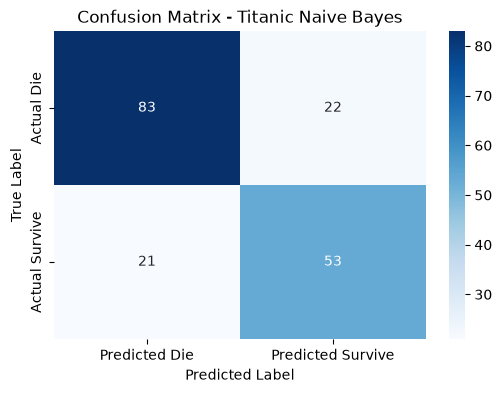

In [15]:
# 1. Generate predictions
y_pred = model.predict(X_test)

# 2. Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 3. Print Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Die', 'Predicted Survive'],
            yticklabels=['Actual Die', 'Actual Survive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Titanic Naive Bayes')
plt.show()

### My Analysis

* **What I did:**
1. Opened up the Titanic dataset (`titanic (2).csv`) and checked which columns had missing values (turned out `Age` had quite a few blanks).
2. Picked out the main features that actually mattered for survival—`Pclass`, `Sex`, `Age`, and `Fare`—and mapped `Sex` to numbers (0 for male, 1 for female) so the model could read it.
3. Used `SimpleImputer` with the median strategy to fill in those missing age spots.
4. Split the data 80/20 for training and testing, and trained a Gaussian Naive Bayes model on it.


* **Model Evaluation & Metrics:**
* **Accuracy:** The model scored an overall accuracy of **76%** on the test split.
* **Confusion Matrix:** Looking at the numbers (`[[83, 22], [21, 53]]`), it correctly guessed 83 people who didn't survive and 53 people who did. But it also messed up on some—getting 22 false positives (guessed they lived when they didn't) and 21 false negatives (guessed they died when they actually made it).
* **Precision & Recall:** It did a bit better with class 0 (did not survive) with an 0.80 precision and 0.79 recall, whereas class 1 (survived) sat around 0.71 precision and 0.72 recall.


* **Conclusion:** Running Naive Bayes was pretty cool because it gave me a decent baseline without needing a super complicated setup, and it really showed how much things like class and gender played a role in who survived!

# Colab Link
https://colab.research.google.com/drive/1z0f6vemmPYJZ5A4xA31wK5riZ3DJFej-?usp=sharing